# 요약 (Summarization)

이번 튜토리얼은 문서 요약을 수행하는 방법에 대해 살펴보겠습니다.

아래는 튜토리얼의 주요 개요입니다.

- Stuff: 전체 문서 한 번에 요약
- Map-Reduce: 분할 요약 후 일괄 병합
- Map-Refine: 분할 요약 후 점진적인 병합
- Chain of Density: N번 반복 실행하며, 누락된 entity를 보완하며 요약 개선
- Clustering-Map-Refine: 문서의 Chunk 를 N 개의 클러스터로 나누고, 각 클러스터에서 중심점에 가까운 문서에 대한 요약을 Refine 요약.

## 대표적으로 알려진 요약 방식

요약기를 구축할 때 중심적인 질문은 문서를 LLM의 컨텍스트 창에 어떻게 전달할 것인가입니다. 이를 위한 몇 가지 알려진 방식은 다음과 같습니다.

1. `Stuff`: 단순히 모든 문서를 단일 프롬프트로 "넣는" 방식입니다. 이는 가장 간단한 접근 방식입니다.

2. `Map-reduce`: 각 문서를 "map" 단계에서 개별적으로 요약한 다음, "reduce" 단계에서 요약본들을 최종 요약본으로 합치는 방식입니다.

3. `Refine`: 입력 문서를 순회하며 반복적으로 답변을 업데이트하여 응답을 구성합니다. 각 문서에 대해, 모든 비문서 입력, 현재 문서, 그리고 최신 중간 답변을 chain에 전달하여 새로운 답변을 얻습니다.



## HCX 연동 
패키지 설치 : pip install -U langchain-naver
가이드 문서 : https://guide.ncloud-docs.com/docs/clovastudio-dev-langchain

In [170]:
pip install -U langchain-naver dotenv langchain-teddynote langchain_community pypdf pymupdf scikit-learn matplotlib seaborn numpy

89363.83s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached numpy-2.3.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
Note: you may need to restart the kernel to use updated packages.


In [171]:
# API KEY를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API KEY 정보로드
load_dotenv()

True

In [10]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip3 install langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("Summary")

LangSmith 추적을 시작합니다.
[프로젝트명]
Summary


## Stuff

`stuff documents chain`("stuff"는 "채우다" 또는 "채우기 위해"의 의미)는 문서 체인 중 가장 간단한 방식입니다. 문서 목록을 가져와서 모두 프롬프트에 삽입한 다음, 그 프롬프트를 LLM에 전달합니다.

이 체인은 문서가 작고 대부분의 호출에 몇 개만 전달되는 애플리케이션에 적합합니다.

전체 문서를 한번에 요약

데이터를 로드합니다.

In [172]:
from langchain_community.document_loaders import TextLoader

# 뉴스데이터 로드
loader = TextLoader("data/news.txt")
docs = loader.load()
print(f"총 글자수: {len(docs[0].page_content)}")
print("\n========= 앞부분 미리보기 =========\n")
print(docs[0].page_content[:500])

총 글자수: 1708

========= 앞부분 미리보기 =========

제목: 
AI2, 상업 활용까지 자유로운 '진짜' 오픈 소스 LLM '올모' 출시

내용:
앨런AI연구소(AI2)가 완전한 오픈 소스 대형언어모델(LLM) '올모(OLMo)’를 출시했다. 데이터 수집, 학습, 배포의 전 과정을 투명하게 공개한 데다 상업적 사용까지 허용한 진정한 의미의 오픈 소스 LLM이라는 평가다.
벤처비트는 1일(현지시간) 비영리 민간 AI 연구기관인 AI2가 ‘최초의 진정한 오픈 소스 LLM 및 프레임워크’라고 소개한 ‘올모’를 출시했다고 보도했다. 
이에 따르면 올모는 모델 코드와 모델 가중치뿐만 아니라 훈련 코드, 훈련 데이터, 관련 툴킷 및 평가 툴킷도 제공한다. 이를 통해 모델이 어떻게 구축되었는지 심층적으로 분석, LLM의 작동 방식과 응답을 생성하는 원리를 더 잘 이해할 수 있다. 
올모 프레임워크는 70억 매개변수의 ‘올모 7B’ 등 4가지 변형 모델과 10억 매개변수의 ‘올모 1B’ 모델을 제공한다. 모델들은 훈련 데이터를 생성하는 코드를 포함해 


아래는 한국어로 요약을 작성하라는 문구가 추가된 prompt 입니다.

In [173]:
from langchain import hub
from langchain.prompts import PromptTemplate

#prompt = hub.pull("teddynote/summary-stuff-documents-korean")
#prompt.pretty_print()

# 요약 지시 프롬프트 
summarize_prompt = """
            다음 REQUEST에 따라 문장을 요약해주세요.
            요구:
            1. 주요 내용을 글머리 기호로 한국어로 요약합니다.
            2. 요약된 각 문장은 각 문장의 의미에 맞는 이모티콘으로 시작되어야 합니다.
            3. 다양한 이모티콘을 활용해 요약을 더욱 흥미롭게 만들어보세요.
            4. 요약본이 영어로 작성된 경우 한국어로 번역합니다.
            5. 어떠한 기술 용어도 번역하지 마십시오.
            6. 불필요한 정보를 포함하지 마십시오.

            문맥:
            {context}

            요약:"       
        """

prompt = PromptTemplate.from_template(summarize_prompt)

In [175]:
from langchain_naver import ChatClovaX
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_teddynote.callbacks import StreamingCallback

llm = ChatClovaX(
    model="HCX-005",
    base_url="https://clovastudio.stream.ntruss.com/v1/openai"
)


# create_stuff_documents_chain( 문서 처리 파이프라인 ) : 문서를 결합하여 모델에 전달하는 역할
# -> 문서를 받아 요약 또는 특정 질문의 대한 답변 
stuff_chain = create_stuff_documents_chain(llm, prompt)

# invoke 방식
answer = stuff_chain.invoke({"context": docs})  
print(answer)
    
# stream 방식
# for chunk in stuff_chain.stream({"context": docs}):
#    print(chunk)





📝

 앨
런
AI
연구소
(A
I
2
)
가
 완전



 오픈
 소스
 L
LM
 '
올
모
(
OL
Mo
)'
를
 출시

했습니다
.
 



💬
 올
모
는
 모델
 코드
,
 가

중
치
,
 훈련
 코드
,
 데이터
,
 툴
킷
 등을
 제공
하여
 심
층
적인
 분석을
 가능하게
 하며
,
 총
 
4
가지
 변
형
 모델
과
 
1
B
 모델을
 제공합니다
.




🚀
 올
모
 프레임
워크
는
 돌
마
 데이터
셋
 기반의
 사전
 훈련



 토큰
과
 함께
 제공
되며
,
 추
론
 코드
,
 훈련
 지표
,
 로그
 등도
 포함되어
 있습니다
.
 또한
 상업
적
 활용
에도
 제한
이
 없습니다
.




⚙
️
 카
네
기
멜
론
대학
은
 빅

테
크
 기업의



 오픈
 소
스가
 실제로
 상업
용
 모델
이며
,
 연구
용으로
만
 제한
되는
 경우가
 많
다고
 비판
했지만
,
 올
모
는
 진정한
 의미
에서의



 오픈
소스
입니다
.




🔍
 한
나
 하지
시
르
지는
 올
모를
 통해
 연구
자들이
 L
LM
 과학
 연구를
 할
 수
 있고
,
 성능
면
에서도
 타
사
 모델
들과
 비슷한
 결과를
 보
였다고
 언급

했습니다
.




🛠
️
 AI
2
는
 올
모를
 계속
 개선
하며
,
 다양한
 모델
 크기
,
 형식
,
 데이터
 셋
 및
 기능을
 추가
할
 계획
입니다
.




🧪
 올
모
의
 목표
는
 단순한
 도구
 제공
이
 아닌
,
 AI
 모델
에
 대한
 깊은
 이해
와
 발전을
 위한
 기반
 마련
입니다
.



💡

 얀
 르

쿤
 메
타
 수석
과학
자는



 오픈
소스
 기반
 모델
이
 생성
 AI
의
 발전
과
 혁신
을
 촉진
한다고
 강조
했으며
,
 활발
한
 커뮤니티
 형
성이
 AI
 미래를
 구축
하는
 가장
 빠른
 길
이라
 말

했습니다
.




📄

 현재
 모든
 리
소
스는
 GitHub
 및
 H
ugging
Face
에서

 무
료

## Map-Reduce

Map-reduce 방식의 요약은 긴 문서를 효율적으로 요약하는 기법입니다. 

이 방법은 먼저 문서를 작은 chunk로 나누는 "map" 단계와, 각 chunk의 요약을 결합하는 "reduce" 단계로 구성됩니다. 

1. Map 단계에서는 각 chunk를 병렬로 요약하고
2. reduce 단계에서는 이 요약들을 하나의 최종 요약으로 통합합니다. 

이 접근법은 대규모 문서를 처리할 때 특히 유용하며, 언어 모델의 토큰 제한을 우회할 수 있게 해줍니다.

![](./images/summarization_use_case_2.png)
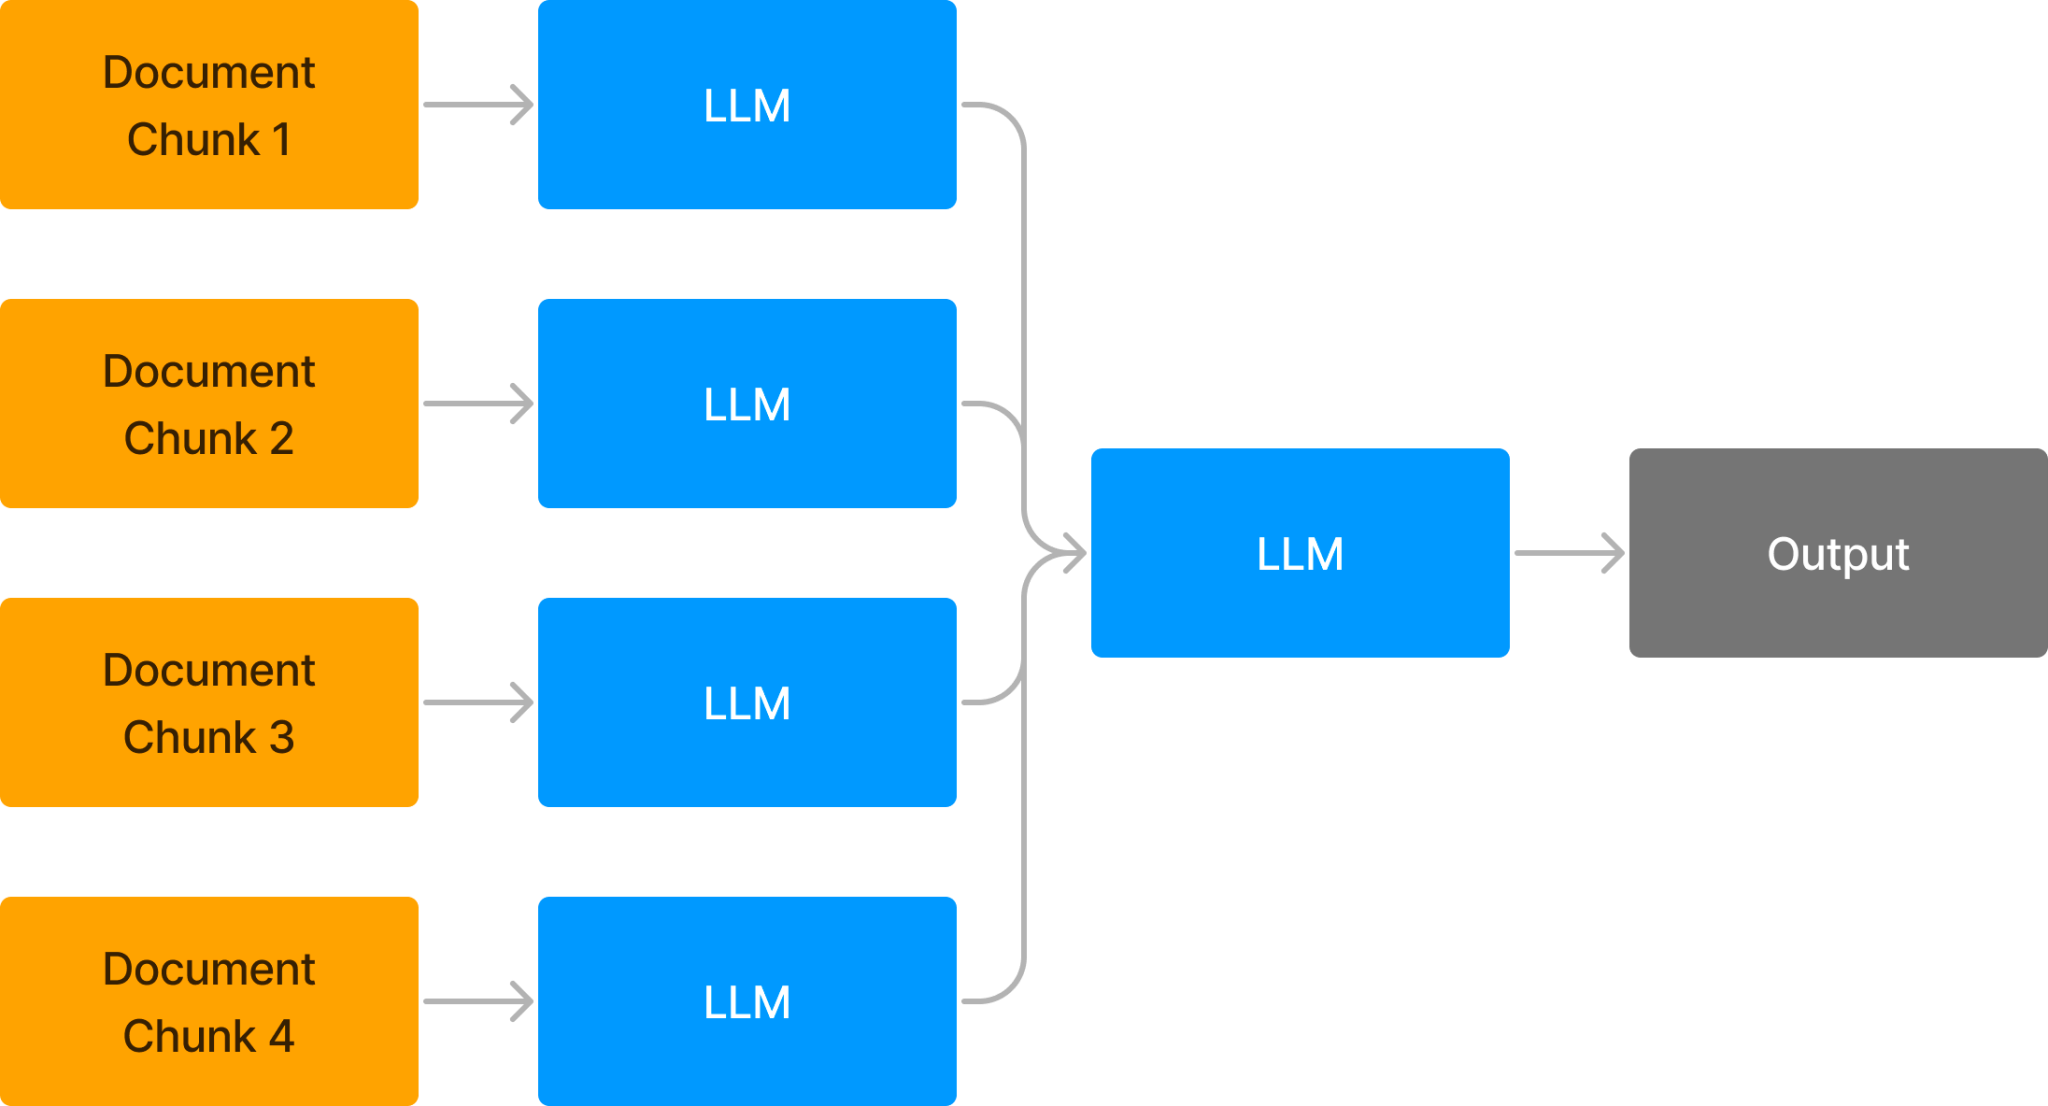

-> Map 
   - 긴 문서의 내용의 핵심을 추출(요약)

-> Reduce 
    - Map에서 추출된 내용을 요약 

데이터를 로드합니다.

In [176]:
from dotenv import load_dotenv #ENV Load
from langchain_community.document_loaders import PyPDFLoader
from langchain.prompts import PromptTemplate
#from langchain_openai import ChatOpenAI
from langchain_naver import ChatClovaX
from langchain import hub
from langchain_core.runnables import chain
from langchain_core.output_parsers import StrOutputParser
from langchain_teddynote.messages import stream_response

loader = PyPDFLoader("data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
docs = docs[3:8]  # 여기서 문서의 일부만 요약
print(f"총 페이지수: {len(docs)}")

총 페이지수: 5


### Map

map 단계에서는 "각 Chunk 에 대한 요약"을 생성합니다. 

(사실 정석은 Chunk 에 대한 요약 생성이지만, 저는 핵심 내용 추출로 변경하여 진행합니다. 어차피 reduce 단계에서 요약을 하나로 합치는 과정이기 때문에 상관없습니다.)

저는 이 방식이 더 유효하다고 생각하였지만, map 단계에 요약을 할지 혹은 핵심 내용을 추출할지는 본인의 판단하에 변경하여 진행할 수 있습니다.

In [178]:
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

llm = ChatClovaX(
    model="HCX-005",
    base_url="https://clovastudio.stream.ntruss.com/v1/openai"
)

# map prompt 다운로드
#map_prompt = hub.pull("teddynote/map-prompt")

# 프롬프트 출력
#map_prompt.pretty_print()


# Pdf 파일의 주요 논문 내용 추출 하는 프롬프트 
prompt = """
    ================================ System Message ==================================

    당신은 전문적인 주요 논문 추출자입니다.

    ================================ Human Message  ==================================

    귀하의 임무는 주어진 문서에서 주요 논문을 추출하는 것입니다. 답변은 해당 문서와 동일한 언어로 작성되어야 합니다. 

    #체재: 
    - 논문 1
    - 논문 2
    - 논문 3
    - ...

    다음은 주어진 문서입니다: 
    {doc}

    1~5문장을 쓰세요.
    #답변:
"""
map_prompt = PromptTemplate.from_template(prompt)

map_chain 을 생성합니다.

In [179]:
# map chain 생성
map_chain = map_prompt | llm | StrOutputParser()

batch() 를 호출하여 각 문서에 대한 요약본을 생성합니다.

In [180]:
# 문서에 대한 주요내용 추출
doc_summaries = map_chain.batch(docs)

# Map을 통해 Chunk 단위로 요약한 데이터 출력 
for i in doc_summaries:
    print("=" * 60)
    print(i)

1. 미국 바이든 대통령은 안전하고 신뢰할 수 있는 AI 개발을 위해 행정명령에 서명했습니다.
2. 이 행정명령에는 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상 등이 포함되어 있습니다.
3. 또한, AI 시스템의 안전성을 확인하기 위한 표준과 AI 생성 콘텐츠 표시를 위한 표준도 함께 추진됩니다.
4. 법률, 주택, 보건 분야에서의 AI 사용으로 인한 차별 방지를 위한 조치들이 확대될 예정입니다.
5. 이와 함께 혁신과 경쟁 촉진을 위해 국가 차원의 AI 연구 인프라 확충이 이루어질 계획입니다.
1. G7이 히로시마 AI 프로세스를 통해 첨단 AI 시스템 개발을 위한 기업 대상의 AI 국제 행동강령에 합의하였습니다.
2. 이 행동강령은 AI의 전 생애 주기에 대한 위험 평가와 완화, 투명성과 책임성 보장, 정보 공유와 이해관계자 간 협력, 보안 통제, 콘텐츠 인증과 출처 확인 등의 내용을 담고 있습니다.
3. G7은 이를 통해 빠르게 발전하는 기술에 대응하며, 필요시 이해관계자와 협의 하에 강령을 개정할 예정입니다.
4. 또한 사회적 위험과 안전·보안 문제 해결 및 글로벌 이슈 해결에 첨단 AI 시스템을 우선 활용하도록 하며, 국제 기술 표준의 개발 및 개인정보와 지식재산권 보호를 위한 조치도 포함되어 있습니다.
5. 이러한 국제적 협력과 규제는 AI 기술의 안전하고 윤리적인 발전을 촉진하기 위한 중요한 발걸음으로 해석됩니다.
1. 영국 블레츨리 파크에서 개최된 AI 안전성 정상회의에 참가한 28개국이 AI 안전 보장을 위한 협력 방안을 담은 블레츨리 선언을 발표했습니다.
2. 이 선언에서는 AI 안전 보장을 위해 모든 이해관계자들의 협력이 필요하며, 특히 최첨단 AI 시스템을 개발하는 기업들이 안전 평가를 비롯한 적절한 조치를 취해야 한다고 강조하였습니다.
3. 이에 따라 각국은 첨단 AI 개발 기업의 투명성 향상, 적절한 평가 지표 및 안전 테스트 도구 개발 등에 대해 협력하기로 했습니다.
4. 리시 수낙 영국 총리는 AI 안전성 정

In [181]:
# 요약된 문서의 수 출력
len(doc_summaries)

5

In [182]:
# 일부 문서의 요약 출력
print(doc_summaries[0])

1. 미국 바이든 대통령은 안전하고 신뢰할 수 있는 AI 개발을 위해 행정명령에 서명했습니다.
2. 이 행정명령에는 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상 등이 포함되어 있습니다.
3. 또한, AI 시스템의 안전성을 확인하기 위한 표준과 AI 생성 콘텐츠 표시를 위한 표준도 함께 추진됩니다.
4. 법률, 주택, 보건 분야에서의 AI 사용으로 인한 차별 방지를 위한 조치들이 확대될 예정입니다.
5. 이와 함께 혁신과 경쟁 촉진을 위해 국가 차원의 AI 연구 인프라 확충이 이루어질 계획입니다.


### Reduce

Reduce 단계에서는 map 단계에서 진행한 핵심 내용들을 하나의 최종 요약으로 통합합니다. 

In [183]:
prompt = """
    ================================ System Message ==================================

    당신은 전문 요약가입니다. 문서 요약 목록이 제공되며 문서의 단일 요약을 작성하라는 메시지가 표시됩니다.

    ================================ Human Message  ==================================

    #지침: 
    1. 문서 요약 목록에서 주요 내용 추출
    2. 글머리 기호 형식으로 최종 요약을 작성합니다.
    3. 답변은 {language}로 작성해야 합니다.

    #체재: 
    - 요약 1
    - 요약 2
    - 요약 3
    - ...

    다음은 문서 요약 목록입니다. 
    {doc_summaries}

    #요약:
"""
reduce_prompt = PromptTemplate.from_template(prompt)



# reduce prompt 다운로드
#reduce_prompt = hub.pull("teddynote/reduce-prompt")

# 프롬프트 출력
#reduce_prompt.pretty_print()

Reduce Chain 을 생성합니다.

In [184]:
# reduce chain 생성
reduce_chain = reduce_prompt | llm | StrOutputParser()

아래는 Reduce Chain 을 사용하여 스트리밍 출력 예시입니다.

In [185]:
from langchain_teddynote.messages import stream_response

answer = reduce_chain.stream(
    {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
)
stream_response(answer)

**주요 내용**
1. 조 바이든 대통령이 안전한 AI 개발을 목표로 한 행정명령에 서명했으며, 여기에는 AI 안전 기준 설정, 개인정보보호, 평등 증진 등이 포함되었습니다.
2. G7은 AI 국제 행동강령에 합의해 AI의 위험 평가, 투명성, 보안 등을 강화하고자 하며, 국제 기술 표준 개발 및 개인정보 보호 조치도 포함시켰습니다.
3. AI 안전성 정상회의에 참여한 28개국은 블레츨리 선언을 통해 AI 안전 협력을 다짐했고, 영국은 AI 안전 연구소를 설립할 계획입니다.
4. 미국 법원에서는 저작권 미등록 작품 문제로 AI 기업 대상 저작권 소송을 기각했으나, 특정 이미지 중심의 재소송 가능성은 열려 있습니다.
5. FTC는 생성형 AI로 인한 소비자 피해와 경쟁 왜곡 우려를 제기하며, AI 시장에 대한 규제 필요성을 강조하고 있습니다.
6. AI 기술의 사회적 영향을 고려한 규제 필요성이 대두되고 있으며, 다양한 국제적 노력이 AI의 안전하고 윤리적인 발전을 촉진하고 있습니다.

**결론**: 세계 각국은 AI의 안전하고 윤리적인 사용을 보장하기 위해 다양한 노력을 기울이고 있으며, 이를 통해 AI 기술의 건전한 발전을 도모하고 사회 전반에 걸친 신뢰를 구축하려 하고 있습니다.

# 모든 과정을 하나의 코드로 만든 예제
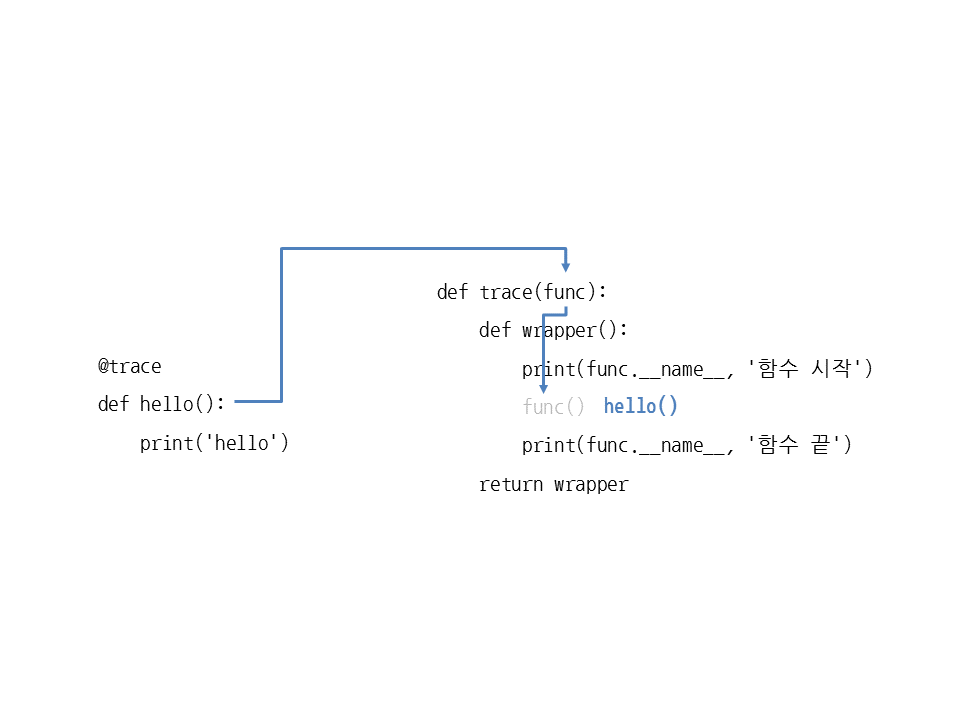

데코레이터 : 함수를 매개변수로 받아 새로운 함수를 반환 

In [186]:
from langchain_core.runnables import chain


@chain
def map_reduce_chain(docs):
    map_llm = ChatClovaX(
            model="HCX-005",
            base_url="https://clovastudio.stream.ntruss.com/v1/openai"
    )

    # map prompt 다운로드
    map_prompt = hub.pull("teddynote/map-prompt")

    # map chain 생성
    map_chain = map_prompt | map_llm | StrOutputParser()

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성합니다.
    doc_summaries = map_chain.batch(docs)

    # reduce prompt 다운로드
    reduce_prompt = hub.pull("teddynote/reduce-prompt")
    
    reduce_llm = ChatClovaX(
            model="HCX-005",
            base_url="https://clovastudio.stream.ntruss.com/v1/openai"
    )
    
    # StrOutputParser -> String 반환 
    reduce_chain = reduce_prompt | reduce_llm | StrOutputParser()

    return reduce_chain.invoke(
        {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
    )

In [187]:
# 결과 출력
answer = map_reduce_chain.invoke(docs)

print(answer)

- 조 바이든 대통령이 안전한 AI 개발을 위한 행정명령에 서명하였고, 이는 AI의 안전과 보안 기준 설정, 개인정보보호, 형평성 및 시민권 증진 등을 포함한다.
- G7은 고급 AI 시스템 개발자에 대한 국제 규약에 동의했으며, 위험 식별 및 완화 조치 등 AI 시스템의 전 생애주기에 걸친 요구사항을 포함시켰다.
- 블레츨리 선언은 28개 국가가 참여하여 AI 위험 관리 및 안전보장에 관한 협력 방안을 제시하였다.
- 미국 캘리포니아 법원은 일부 예술가의 저작권 침해 소송을 기각하였으나, 저작권 보유 확인된 사례에서는 소송을 지속하도록 하였다.
- 미국 FTC는 생성형 AI의 잠재적 위험성에 대해 우려를 나타내며, 창작자와 소비자의 보호를 위해 법적 권한을 활용할 것임을 밝혔다.


## Map-Refine
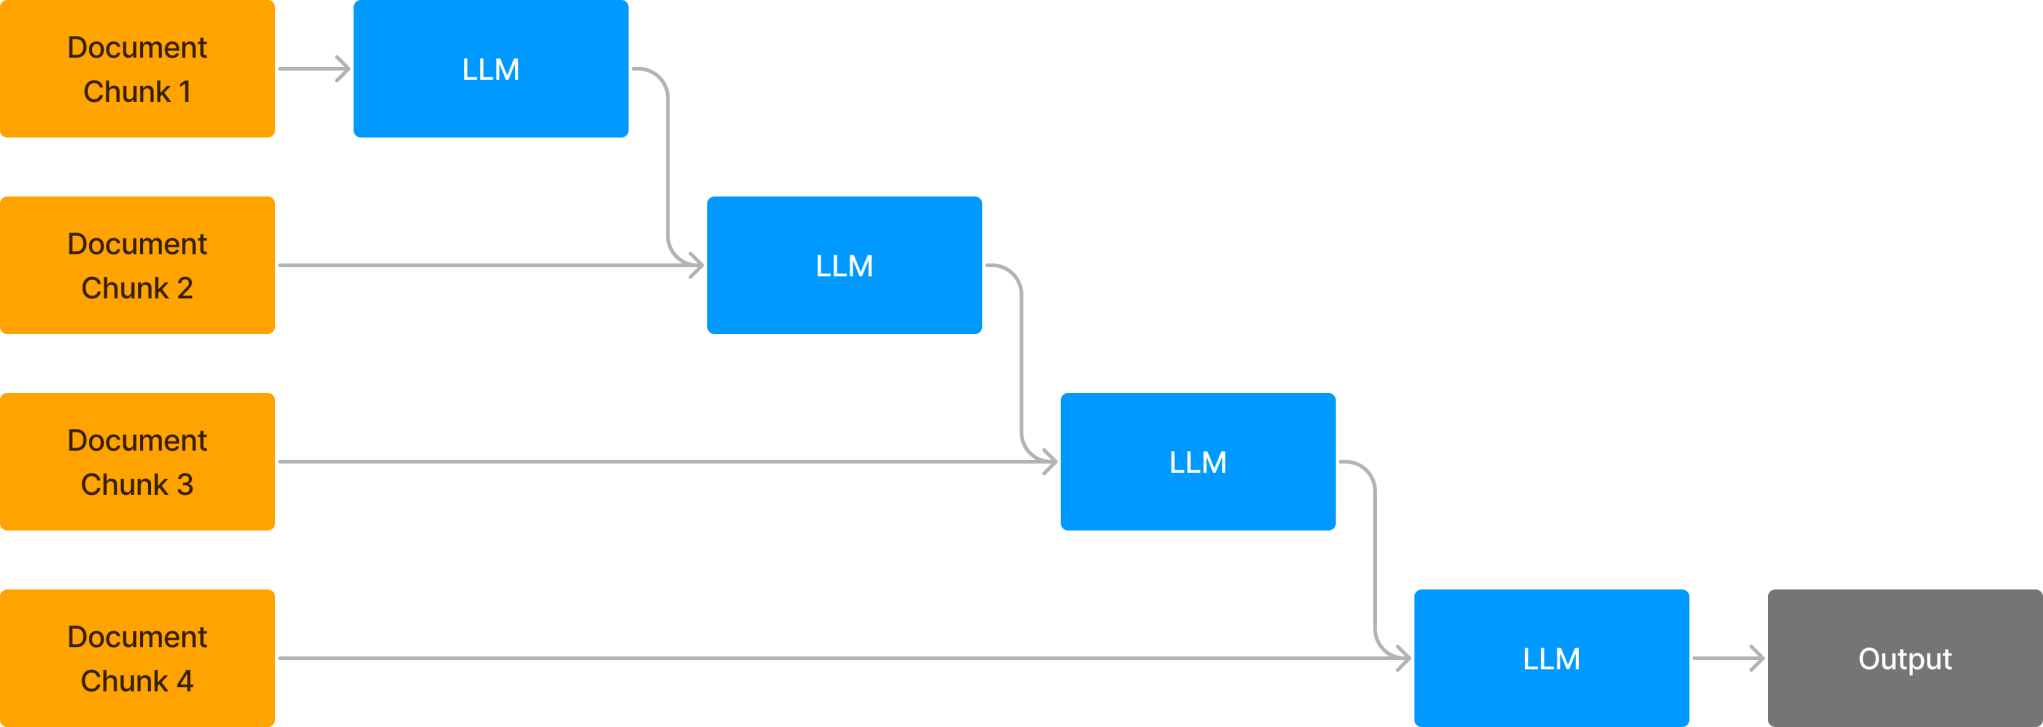
Map-refine 방식은 문서 요약을 위한 또 다른 접근법으로, map-reduce와 유사하지만 약간의 차이가 있습니다. 

1. Map 단계: 문서를 여러 개의 작은 chunk로 나누고, 각 chunk에 대해 개별적으로 요약을 생성합니다.

2. Refine 단계: 생성된 요약들을 순차적으로 처리하며 최종 요약을 점진적으로 개선합니다. 각 단계에서 이전 요약과 새로운 chunk의 정보를 결합하여 요약을 갱신합니다.
   
3. 반복 과정: 모든 chunk가 처리될 때까지 refine 단계를 반복합니다.

4. 최종 요약: 마지막 chunk까지 처리한 후 얻은 요약이 최종 결과가 됩니다.

map-refine 방식의 장점은 문서의 순서를 유지하면서 점진적으로 요약을 개선할 수 있다는 것입니다. 이는 특히 문서의 맥락이 중요한 경우에 유용할 수 있습니다. 그러나 이 방식은 map-reduce 에 비해 순차적으로 처리되기 때문에 병렬화가 어려워 대규모 문서 처리 시 시간이 더 오래 걸릴 수 있습니다.



Map Reduce 는 Map 단계에서 여러 문서를 chunk로 나눠 하나의 요약을 생성 하여 Reduce 단계에서 최종요약을 도출

Map Refune 은 Map 단계에서 여러 문서를 chunk로 나눠 개별적인 요약을 생성 하여 Refine 단계에서 개별적인 요약을 도출
![](./images/summarization_use_case_3.png)


이전 요약을 현재 요약에 담아 결과를 도출

### Map

map 단계에서는 각 Chunk 에 대한 요약을 생성합니다. 

In [188]:
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import PromptTemplate
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
docs = docs[3:8]  # 여기서 문서의 일부만 요약
print(f"총 페이지수: {len(docs)}")

# map llm 생성
llm = ChatClovaX(
    model="HCX-005",
    base_url="https://clovastudio.stream.ntruss.com/v1/openai"
)

# 가장 중요한 주제를 추출하는 프롬프트 
map_summary = """
    ================================ System Message ==================================

    당신은 전문적인 주요 논문 추출자입니다.
    당신은 전문 요약가입니다. 귀하의 임무는 다음 문서를 {language}로 요약하는 것입니다.


    ================================ Human Message  ==================================

    문서에서 가장 중요한 주요 주제를 추출한 다음 글머리 기호로 요약합니다.

    #체재:
    - 요약 1
    - 요약 2
    - 요약 3
    -...

    다음은 주어진 문서입니다: 
    {documents}

    1~5문장을 쓰세요. 단계별로 생각해보세요.
    #요약:
"""
map_summary = PromptTemplate.from_template(map_summary)
# map chain 생성
#map_summary = hub.pull("teddynote/map-summary-prompt")

# 프롬프트 출력
#map_summary.pretty_print()

총 페이지수: 5


map_chain 을 생성합니다.

In [189]:
# map chain 생성
map_chain = map_summary | llm | StrOutputParser()

첫 번째 문서에 대한 요약본을 출력합니다.

In [190]:
# 첫 번째 문서의 요약 출력
print(map_chain.invoke({"documents": docs[0], "language": "Korean"}))

**요약**

- 미국 바이든 대통령은 안전하고 신뢰할 수 있는 AI 개발을 위해 일련의 행정 명령에 서명했으며, 이는 AI의 안전과 보안 기준 설정, 개인정보보호, 형평성과 시민권 향상 등을 포함합니다.
- 해당 명령에는 강력한 AI 시스템을 개발한 기업들이 안전 테스트 결과를 공유하도록 하며, 특정 컴퓨팅 성능을 넘는 모델들이 정보 공유 대상이 됩니다.
- 또한 법 집행부터 건강 관리까지 다양한 영역에서의 AI 남용으로 인한 부정적 영향을 줄이기 위한 여러 조치가 포함되어 있습니다.
- 소비자 보호와 노동자 지원을 강화하고자 의료 분야에서의 책임감 있는 AI 사용을 촉진하고, 학교에서의 AI 교육 자원도 개발될 예정입니다.
- 마지막으로 혁신과 경쟁 촉진을 위해 전국 단위의 AI 연구 자원 프로그램이 구축되고 비자 요건 개선 등으로 외국인 인재 유치도 장려됩니다.


In [191]:
# 모든 문서를 입력으로 정의합니다.
input_doc = [{"documents": doc, "language": "Korean"} for doc in docs]

In [192]:
input_doc

[{'documents': Document(metadata={'producer': 'Hancom PDF 1.3.0.542', 'creator': 'Hwp 2018 10.0.0.13462', 'creationdate': '2023-12-08T13:28:38+09:00', 'author': 'dj', 'moddate': '2023-12-08T13:28:38+09:00', 'pdfversion': '1.4', 'source': 'data/SPRI_AI_Brief_2023년12월호_F.pdf', 'total_pages': 23, 'page': 3, 'page_label': '4'}, page_content='1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 n미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고 광범위한 행정 조치를 명시n행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\nKEY Contents\n£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진n미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 행정명령을 발표∙행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄n(AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한 주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한 표준 및 AI 생성 콘텐츠 표시를 위한 표준과 모범사례 확립을 추진∙△1026 플롭스(FLOPS, Floating Point Operation Per Second)를

In [194]:
# 모든 문서에 대한 요약본을 출력합니다.
#invoke
# -> chain에 단 하나의 입력을 넣어 출력을 반환하는 함수

#batch
# -> chain에 복수의 입력을 넣어 각 입력에 따른 출력을 반환하는 함수 

#stream
# -> 실시간으로 출력을 반환하는 함수 

print(map_chain.batch(input_doc))

['# 요약:\n\n- 미국 바이든 대통령은 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령에 서명하였으며, 이는 AI의 안전과 보안, 개인정보보호, 형평성과 시민권 향상 등의 내용을 포함합니다.\n- 행정명령에는 강력 AI 시스템 개발을 위한 기업의 안전 테스트 결과 공유, 형사 사법 시스템에서의 AI 사용 모범 사례 개발 등이 명시되어 있습니다.\n- 또한 소비자 보호와 노동자 지원을 위해 의료 분야에서의 책임있는 AI 사용 촉진과 AI로 인한 근로자 피해 완화를 위한 원칙 등을 제시하였습니다.\n- 혁신과 경쟁 촉진을 위해 국가 차원의 AI 연구 인프라 확충 계획도 포함되어 있으며, 이를 통해 중소기업과 개발자들에게 기술과 인프라를 지원하게 됩니다.\n- 마지막으로 비자 기준과 인터뷰 절차의 현대화 및 간소화를 통해 AI 전문가들이 미국에서 활동할 수 있도록 돕는 내용도 담겨있습니다.', '- G7은 히로시마 AI 프로세스를 통해 첨단 AI 시스템 개발을 위한 기업의 자발적 채택을 권고하는 AI 국제 행동강령에 합의했습니다.\n- 이 행동강령은 AI 위험 식별과 완화, 투명성과 책임성 보장, 정보 공유와 협력, 보안 통제, 콘텐츠 인증과 출처 확인 등을 요구하며, 기술의 빠른 발전에 대응하기 위해 이해관계자 협의를 통한 개정이 가능합니다.\n- 또한 사회적 위험과 안전·보안 문제 해결, 기후 위기 대응 등에 첨단 AI 시스템을 우선 개발하며, 국제 기술 표준 개발 및 개인정보와 지식재산권을 위한 보호 장치도 구현합니다.', "**요약**\n\n- 영국 블레츨리 파크에서 개최된 AI 안전성 정상회의에는 28개국이 참여하였으며, 이들은 AI 안전보장을 위한 협력 방안인 '블레츨리 선언'을 발표하였다.\n- 이 선언문은 AI안전보장을 위해 모든 이해 관계자들의 협력이 필요함을 강조하였고, 특히 첨단 AI 시스템을 개발하는 기업들이 안전 평가를 비롯한 적절한 조치를 취해야 함을 명시했다.\n- 회의에서는 각국이 첨단 AI 개발 기업의 투명성 향상 및 

### Refine

Refine 단계에서는 이전의 map 단계에서 생성한 chunk들을 순차적으로 처리하며 최종 요약을 점진적으로 개선합니다. 

In [196]:
# refine prompt 다운로드
#refine_prompt = hub.pull("teddynote/refine-prompt")

# 프롬프트 출력
#refine_prompt.pretty_print()

refine_prompt = '''
================================ System Message ================================

당신은 전문 요약가입니다.

================================ Human Message =================================

귀하의 임무는 최종 요약을 작성하는 것입니다.

우리는 특정 지점까지의 기존 요약을 제공했습니다.
{previous_summary}

아래에 더 많은 맥락을 추가하여 기존 요약을 (필요한 경우에만) 개선할 수 있는 기회가 있습니다.
------------
{current_summary}
------------
새로운 맥락을 고려하여 원래 요약을 {language} 로 수정하세요.
컨텍스트가 유용하지 않으면 원래 요약을 반환하세요.
'''

refine_prompt = PromptTemplate.from_template(refine_prompt)


In [197]:
# refine llm 생성
# refine_llm = ChatOpenAI(
#     temperature=0,
#     model_name="gpt-4o-mini",
# )

refine_llm = ChatClovaX(
    model="HCX-005",
    base_url="https://clovastudio.stream.ntruss.com/v1/openai"
)

# refine chain 생성
refine_chain = refine_prompt | refine_llm | StrOutputParser()


아래는 map_refine_chain 을 생성하는 예시입니다. 

지금까지의 일련의 과정을 하나의 chain 으로 엮습니다.

In [198]:
from langchain_core.runnables import chain


@chain
def map_refine_chain(docs):

    # map chain 생성
    map_summary = hub.pull("teddynote/map-summary-prompt")

    map_chain = (
        map_summary
        | ChatClovaX(
            model="HCX-005",
            base_url="https://clovastudio.stream.ntruss.com/v1/openai",
            temperature=0,
        )
        | StrOutputParser()
    )

    input_doc = [{"documents": doc.page_content, "language": "Korean"} for doc in docs]

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성합니다.
    doc_summaries = map_chain.batch(input_doc)

    #print('=' * 60 )
    #print(doc_summaries)
    #print('=' * 60 )

    #refine_prompt = hub.pull("teddynote/refine-prompt")

    refine_prompt = '''
    ================================ System Message ================================

    당신은 요약 전문가입니다.

    ================================ Human Message =================================

    귀하의 임무는 최종 요약을 작성하는 것입니다.

    아래 데이터는 이전 시점의 요약 데이터입니다. 
    {previous_summary}

    아래에 더 많은 문구를 추가하여 기존 요약을 (필요한 경우에만) 개선할 수 있는 기회가 있습니다.
    ------------
    {current_summary}
    ------------
    새로운 문구를 고려하여 요약을 {language} 로 수정하세요.
    문구가 유용하지 않으면 이전 요약을 반환하세요.
    '''

    refine_prompt = PromptTemplate.from_template(refine_prompt)

    refine_llm = ChatClovaX(
        model="HCX-005",
        base_url="https://clovastudio.stream.ntruss.com/v1/openai",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    refine_chain = refine_prompt | refine_llm | StrOutputParser()

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:
        #print("previous_summary:" + previous_summary)
        #print("current_summary:" + current_summary)

        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary, #이전 요약
                "current_summary": current_summary, #현재 요약 
                "language": "Korean",
            }
        )
        print("\n\n-----------------\n\n")

    return previous_summary

In [199]:
refined_summary = map_refine_chain.invoke(docs)

미국 바이든 대통령은 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명해 AI의 안전과 보안, 개인정보보호 등 여러 행정 조치를 규정했으며, 이에 따라 기업은 안전 테스트 결과를 정부에 보고해야 하고 법 집행 기관 내 AI 오남용을 방지하기 위한 지침을 만들며, 국가 차원에서 AI 연구 인프라를 구축하게 됩니다.

또한, G7는 ‘히로시마 AI 프로세스’를 통해 AI 시스템의 위험성을 식별하고 완화하며, 투명성과 책임성을 보장하고 정보 공유와 협력을 강화하는 등의 국제 행동 강령을 마련했고, 이를 통해 사회적 위험과 안전 문제를 해결하고 기후 위기에 대응하는 데 초점을 맞추며, 국제 기술 표준을 개발하고 개인정보와 지식 재산권을 보호하려는 노력을 기울이고 있습니다.

이와 같은 국제적 협력을 통해 AI 기술의 안전하고 윤리적인 발전을 촉진하고자 합니다. 

-----------------


미국 바이든 대통령은 '안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령'에 서명하여 AI의 안전과 보안, 개인정보보호 등을 규정하였으며, 기업들은 안전 테스트 결과를 정부에 보고해야 하며 법 집행 기관 내 AI 오용 방지를 위한 지침을 만들고 국가 차원에서의 AI 연구 인프라를 구축합니다. G7은 '히로시마 AI 프로세스'를 통해 AI 시스템의 위험성을 식별하고 완화하며, 투명성과 책임성을 보장하고 정보 공유와 협력을 강화하는 국제 행동 강령을 마련하여 사회적 위험과 안전 문제 해결, 기후 위기 대응, 국제 기술 표준 개발, 개인정보와 지식재산권 보호에 주력하고 있습니다. 이러한 국제적 협력을 통해 AI 기술의 안전하고 윤리적인 발전을 촉진하고자 합니다.

영국 블레츨리 파크에서 열린 AI 안전성 정상회의에서는 28개국이 참여하여 '블레츨리 선언'을 발표했습니다. 이 선언문은 AI 안전 보장을 위해 모든 이해 관계자의 협력이 필요하며, 특히 첨단 AI 시스템 개발을 하는 기업들이 안전 평가를 비롯한 적절한 조치를 취해야 함을 강조합니다. 또한

## Chain of Density

- 논문: https://arxiv.org/pdf/2309.04269

"Chain of Density" (CoD) 프롬프트는 GPT-4를 사용한 요약 생성을 개선하기 위해 개발된 기법입니다. 

이 방법은 초기에 개체가 적은 요약을 생성한 후, 길이를 늘리지 않으면서 누락된 중요 개체들을 반복적으로 통합하는 과정을 거칩니다. 연구 결과, CoD로 생성된 요약은 일반 프롬프트보다 더 추상적이고 정보 융합이 뛰어나며, 인간이 작성한 요약과 비슷한 밀도를 가진 것으로 나타났습니다.

1. 점진적 개선: CoD는 초기에 개체가 적은 간단한 요약을 생성한 후, 단계적으로 중요한 개체들을 추가하며 요약을 개선합니다. 이 과정에서 요약의 길이는 유지되면서 정보 밀도가 증가하여 읽기 쉬우면서도 정보량이 풍부한 요약이 만들어집니다.

2. 정보 밀도와 가독성의 균형: CoD 방식은 요약의 정보 밀도를 조절하여 정보성과 가독성 사이의 최적 균형점을 찾습니다. 연구 결과에 따르면, 사람들은 일반적인 GPT-4 요약보다 더 밀도 있지만 사람이 작성한 요약만큼 밀도가 높지 않은 CoD 요약을 선호하는 것으로 나타났습니다.

3. 추상화와 정보 융합 개선: CoD로 생성된 요약은 더 추상적이고 정보 융합이 뛰어나며, 원문의 앞부분에 치우치는 경향(lead bias)이 덜합니다. 이는 요약의 전반적인 품질과 가독성을 향상시키는 데 기여합니다.





-> 프롬프트를 사용하여, 점점 더 Entity의 density(밀도)가 높아지도록 요약을 요청

1. 먼저 LLM에게 원 글에 대해 Summary를 생성하도록 요청한다.
2. Summary를 생성한 요약문에서 'Missing Entity'를 찾도록 요청한다.  
3. 이전 Summary에 Missing Entity를 추가하여 다시 Summary를 생성하게 하되,
    길이는 유지하여 Summary의 entity-density를 높인다.
4. 위의 2번과 3번 과정을 약 5회 반복한다.



[Chain of Density Prompt](https://smith.langchain.com/prompts/chain-of-density-prompt/4582aae0?organizationId=8c9eeb3c-2665-5405-bc50-0767fdf4ca8f)

**입력 파라미터 설명**

- `content_category`: 콘텐츠 정류(예: 기사, 동영상 녹취록, 블로그 게시물, 연구 논문). 기본값: Article

- `content`: 요약할 콘텐츠

- `entity_range`: 콘텐츠에서 선택하여 요약에 추가할 엔티티의 수의 범위. 기본값은 `1-3`

- `max_words`: 1번 요약시, 요약에 포함할 최대 단어. 기본값은 **80** 입니다.

- `iterations`: 엔티티 고밀도화 라운드 수. 총 요약은 **반복 횟수+1** 입니다. 80단어의 경우 3회 반복이 이상적입니다. 요약이 더 길면 4~5회, 그리고 `entity_range` 를 예를 들어 1~4로 변경하는 것도 도움이 될 수 있습니다. 기본값: 3.

이 코드는 Chain of Density 프롬프트를 사용하여 텍스트 요약을 생성하는 체인을 구성합니다.

첫 번째 체인은 중간 결과를 보여주고, 두 번째 체인은 최종 요약만을 추출합니다.

================================ 시스템 메시지 ================================

당신은 전문 카피라이터입니다. 사용자가 제공한 {content_category}를 읽고, 점차 더 간결하고 정보 밀도가 높은 요약문을 작성하십시오.  
첫 번째 요약은 반드시 {max_words}단어 이하로 작성되어야 하며, {content_category}에서 추출한 {entity_range}개의 유익한 핵심 정보 단위(Descriptive Entities)를 포함해야 합니다.

◆ 핵심 정보 단위(Descriptive Entity)란?
- **관련성 있음**: 이야기의 핵심에 해당함
- **구체적임**: 5단어 이하의 간결한 묘사
- **사실 기반**: 실제 {content_category} 내에 존재해야 함
- **위치 무관**: 본문의 어디에 위치하든 상관없음

# 요약 작성 절차

1. {content_category} 전체를 정독하여 내용을 파악합니다.
2. {entity_range}개의 유익한 Descriptive Entity를 선택하고 세미콜론(;)으로 구분해 나열합니다. (예: "삼성전자;2분기 실적;반도체 적자")
3. 위 정보를 포함하여, 최대 {max_words}단어로 첫 번째 요약을 작성합니다.
   - 이 요약은 **고의적으로 매우 모호하고 일반적인 내용**으로 작성하며, 가능한 한 Descriptive Entity 외의 정보는 거의 포함하지 않도록 합니다.
   - 예: “이 {content_category}에서는 여러 요소들이 상호작용하며 중요한 이슈를 형성하고 있으며, 특히 {entity1}, {entity2}가 핵심적인 주제를 이룹니다.”

그 후, 다음 단계를 {iterations}번 반복합니다:

## 반복 단계 (총 {iterations}회 반복)

- **1단계**: 이전 요약에서 누락된 새로운 Descriptive Entity {entity_range}개를 식별합니다.
- **2단계**: 이전 요약의 모든 내용을 유지하면서, 새로운 Descriptive Entity들을 추가하여 동일한 단어 수로 더 밀도 높은 요약을 작성합니다.

◆ 참고 사항
- 기존 요약에서 사용된 Descriptive Entity는 절대 제거하지 마세요.
- 공간이 부족할 경우, 새롭게 추가할 Descriptive Entity 수를 줄일 수 있습니다.
- 요약은 점점 더 구체적이고, 정보가 압축되어야 하며, 최종 요약은 본문 없이도 내용을 이해할 수 있어야 합니다.

# 출력 형식 (JSON)

다음과 같은 구조로 JSON 리스트를 출력하세요:

[
  {
    "missing_entities": "엔티티1;엔티티2",
    "denser_summary": "엔티티1과 엔티티2를 포함한 매우 모호한 첫 요약"
  },
  {
    "missing_entities": "엔티티3",
    "denser_summary": "엔티티1, 엔티티2, 엔티티3이 모두 포함된 더 압축된 요약"
  },
  
]


In [87]:
# Chain of Density 프롬프트 다운로드
cod_prompt = hub.pull("teddynote/chain-of-density-prompt")

cod_prompt.pretty_print()

================================ System Message ================================

As an expert copy-writer, you will write increasingly concise, entity-dense summaries of the user provided {content_category}. The initial summary should be under {max_words} words and contain {entity_range} informative Descriptive Entities from the {content_category}.

A Descriptive Entity is:
- Relevant: to the main story.
- Specific: descriptive yet concise (5 words or fewer).
- Faithful: present in the {content_category}.
- Anywhere: located anywhere in the {content_category}.

# Your Summarization Process
- Read through the {content_category} and the all the below sections to get an understanding of the task.
- Pick {entity_range} informative Descriptive Entities from the {content_category} (";" delimited, do not add spaces).
- In your output JSON list of dictionaries, write an initial summary of max {max_words} words containing the Entities.
- You now have `[{"missing_entities": "...", "denser_summa

### 프롬프트 요약 


In [130]:
import textwrap
from langchain import hub
from langchain_naver import ChatClovaX
from langchain_core.output_parsers import SimpleJsonOutputParser

# {content}를 제외한 모든 입력에 대한 기본값 지정
# lambda 인자 : 표현식
cod_chain_inputs = {
    "content": lambda d: d.get("content"), # 요약할 콘텐츠
    "content_category": lambda d: d.get("content_category", "Article"), #콘텐츠 정류(예: 기사, 동영상 녹취록, 블로그 게시물, 연구 논문). 기본값: Article
    "entity_range": lambda d: d.get("entity_range", "1-3"), # 콘텐츠에서 선택하여 요약에 추가할 엔티티의 수의 범위. 기본값은 `1-3`
    "max_words": lambda d: int(d.get("max_words", 80)), # 1번 요약시, 요약에 포함할 최대 단어. 기본값은 **80** 입니다.
    "iterations": lambda d: int(d.get("iterations", 5)), # 엔티티 고밀도화 라운드 수. 총 요약은 **반복 횟수+1** 입니다. 80단어의 경우 3회 반복이 이상적입니다
}

# Chain of Density 프롬프트 다운로드
cod_prompt = hub.pull("teddynote/chain-of-density-prompt")

# Chain of Density 체인 생성
cod_chain = (
    cod_chain_inputs # Prompt 변수 
    | cod_prompt # 프롬프트
    # | ChatClovaX(temperature=0, model="HCX-005", base_url="https://clovastudio.stream.ntruss.com/v1/openai") #Model
    | ChatOpenAI(temperature=0, model="gpt-4o-mini")
    | SimpleJsonOutputParser() #Json OutPut Parser
)

#두 번째 체인 생성, 최종 요약만 추출 (스트리밍 불가능, 최종 결과가 필요함)
cod_final_summary_chain = cod_chain | (
                                        lambda output: output[-1].get(
                                        "denser_summary", '오류: 마지막 딕셔너리에 "denser_summary" 키가 없습니다'
                                        )
                                        )


요약할 데이터를 확인합니다.

In [113]:
content = docs[1].page_content
print(content)

SPRi AI Brief |  2023-12월호
2
G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의nG7이 첨단 AI 시스템을 개발하는 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 채택을 권고하는 AI 국제 행동강령을 마련n행동강령은 AI 수명주기 전반에 걸친 위험 평가와 완화, 투명성과 책임성의 보장, 정보공유와 이해관계자 간 협력, 보안 통제, 콘텐츠 인증과 출처 확인 등의 조치를 요구
KEY Contents
£G7, 첨단 AI 시스템의 위험 관리를 위한 국제 행동강령 마련n주요 7개국(G7)*은 2023년 10월 30일 ‘히로시마 AI 프로세스’를 통해 AI 기업 대상의 AI 국제 행동강령(International Code of Conduct for Advanced AI Systems)에 합의∙G7은 2023년 5월 일본 히로시마에서 개최된 정상회의에서 생성 AI에 관한 국제규범 마련과 정보공유를 위해 ‘히로시마 AI 프로세스’를 출범**∙기업의 자발적 채택을 위해 마련된 이번 행동강령은 기반모델과 생성 AI를 포함한 첨단 AI 시스템의 위험 식별과 완화에 필요한 조치를 포함* 주요 7개국(G7)은 미국, 일본, 독일, 영국, 프랑스, 이탈리아, 캐나다를 의미** 5월 정상회의에는 한국, 호주, 베트남 등을 포함한 8개국이 초청을 받았으나, AI 국제 행동강령에는 우선 G7 국가만 포함하여 채택nG7은 행동강령을 통해 아래의 조치를 제시했으며, 빠르게 발전하는 기술에 대응할 수 있도록 이해관계자 협의를 통해 필요에 따라 개정할 예정∙첨단 AI 시스템의 개발 과정에서 AI 수명주기 전반에 걸쳐 위험을 평가 및 완화하는 조치를 채택하고, 첨단 AI 시스템의 출시와 배포 이후 취약점과 오용 사고, 오용 유형을 파악해 완화∙첨단 AI 시스템의 성능과 한계를 공개하고 적절하거나 부적절한 사용영역을 알리는 방법으로 투명성을 보장하고 책임성을 강화∙산업계, 정부, 시민사회, 학계를 포함해 첨단 AI 시스템을 개발하는 조직 간 정보

부분 JSON 스트리밍하기. 스트리밍된 각 청크는 새로운 접미사가 추가된 동일한 JSON 딕트 목록입니다. 

따라서 단순히 연결하는 것이 아니라 다음 청크가 이전 청크를 덮어쓰고 반복적으로 스트리밍을 추가하는 것처럼 보이게 하려면 `\r` 캐리지 리턴 인쇄가 필요합니다.

In [131]:
# 결과를 저장할 빈 리스트 초기화
results: list[dict[str, str]] = []


# cod_chain을 스트리밍 모드로 실행하고 부분적인 JSON 결과를 처리
for partial_json in cod_chain.stream(
    {"content": content, "content_category": "Article", "iterations":  5} # Prompt 변수 지정 
):
    # 각 반복마다 results를 업데이트
    results = partial_json

    # 현재 결과를 같은 줄에 출력 (캐리지 리턴을 사용하여 이전 출력을 덮어씀)
    print(results, end="\r", flush=True)

# 총 요약 수 계산
total_summaries = len(results)
print("\n")

#print( "partial_json  : " + str(results) )

# missing_entities : 누락된 엔티티
# denser_summary : 밀도있는 요약 

# 각 요약을 순회하며 처리
i = 1
for cod in results:
    # 누락된 엔티티들을 추출하고 포맷팅
    print("cod : ", cod)

    added_entities = ", ".join(
        [
            ent.strip()
            for ent in cod.get(
                "missing_entities", 'ERR: "missing_entiies" key not found' # OutPut missing_entities 체크
            ).split(";")
        ]
    )
    # 더 밀도 있는 요약 추출
    summary = cod.get("denser_summary", 'ERR: missing key "denser_summary"') # OutPut denser_summary 체크

    # 요약 정보 출력 (번호, 총 개수, 추가된 엔티티)
    print(
        f"### CoD Summary {i}/{total_summaries}, 추가된 엔티티(entity): {added_entities}"
        + "\n"
    )
    # 요약 내용을 80자 너비로 줄바꿈하여 출력
    print(textwrap.fill(summary, width=80) + "\n")
    i += 1

print("\n============== [최종 요약] =================\n")
print(summary)

[{'missing_entities': 'G7;AI 국제 행동강령;히로시마 AI 프로세스', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 책임성, 정보 공유 및 보안 통제를 요구한다.'}, {'missing_entities': 'AI 위험 식별;투명성;정보 공유', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성 보장, 정보 공유 및 보안 통제를 요구한다.'}, {'missing_entities': 'AI 수명주기;보안 통제;콘텐츠 인증', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성 보장, 정보 공유, 보안 통제 및 콘텐츠 인증을 요구한다.'}, {'missing_entities': 'AI 거버넌스;사회적 위험;기후 위기', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 합의했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성 보장, 정보 공유, 보안 통제, 콘텐츠 인증, AI 거버넌스 및 사회적 위험 완화를 요구한다.'}, {'missing_entities': 'AI 시스템;세계적 난제;데이터 보호', 'denser_summary': 'G7은 2023년 10월 30일 히로시마 AI

In [115]:
print(summary)

G7's AI Code of Conduct emphasizes risk assessment, transparency, collaboration across sectors, robust security controls, and content verification mechanisms for advanced AI systems, adapting to rapid technological changes.


In [125]:
result =  cod_chain.invoke({"content": content, "content_category": "Article"})


print("\n============== [최종 요약] =================\n")
print(result[-1]['denser_summary'])



============== [최종 요약] =================

G7's AI Code of Conduct emphasizes risk assessment, transparency, collaboration across sectors, robust security controls, and content verification mechanisms for advanced AI systems, adapting to rapid technological changes.


## Clustering-Map-Refine

이 튜토리얼의 원 저자인 gkamradt 은 긴 문서의 요약에 대해서 흥미로운 제안을 하였습니다.

배경은 다음과 같습니다.

1. map-reduce 나 map-refine 방식은 모두 시간이 오래 걸리고, 비용이 많이 듬.
2. 따라서, 문서를 몇 개(N 개)의 클러스터로 나눈 뒤, 가장 중심축에서 가까운 문서를 클러스터의 대표 문서로 인지하고, 이를 map-reduce(혹은 map-refine) 방식으로 요약하는 방식을 제안.

실제로 비용도 합리적으로, 결과도 만족스럽기 때문에 원 저자의 튜토리얼의 코드를 수정하여 공유합니다.

- [원 저자 및 출처 - gkamradt](https://github.com/gkamradt/langchain-tutorials/blob/main/data_generation/5%20Levels%20Of%20Summarization%20-%20Novice%20To%20Expert.ipynb)

In [143]:
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()
len(docs)

23

아래의 코드를 실행하면 하나의 문서로 텍스트를 합칩니다. 합치는 목적은 page 별로 구분하지 않기 위해서입니다.

합쳐진 문자수는 약 28K 입니다.

In [139]:
# 하나의 Text 로 모든 문서를 연결합니다.
texts = "\n\n".join([doc.page_content for doc in docs])
len(texts)

27977

`RecursiveCharacterTextSplitter` 를 사용하여 하나의 Text 를 여러 문서로 나눕니다.

In [144]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100) #text를 500 size 로 나누기
split_docs = text_splitter.split_text(texts)

나누어진 문서의 수를 확인합니다. 여기서는 79개의 문서로 나누었습니다.

In [149]:
# 총 문서의 수 확인
len(split_docs)

print(split_docs)

['2023년 12월호', '2023년 12월호\nⅠ. 인공지능 산업 동향 브리프\n 1. 정책/법제 \n   ▹ 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표  ························· 1\n   ▹ G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의··························· 2\n   ▹ 영국 AI 안전성 정상회의에 참가한 28개국, AI 위험에 공동 대응 선언··························· 3\n   ▹ 미국 법원, 예술가들이 생성 AI 기업에 제기한 저작권 소송 기각····································· 4\n   ▹ 미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 측면의 AI 의견서 제출················· 5', '▹ 미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 측면의 AI 의견서 제출················· 5\n   ▹ EU AI 법 3자 협상, 기반모델 규제 관련 견해차로 난항··················································· 6\n \n 2. 기업/산업 \n   ▹ 미국 프런티어 모델 포럼, 1,000만 달러 규모의 AI 안전 기금 조성································ 7\n   ▹ 코히어, 데이터 투명성 확보를 위한 데이터 출처 탐색기 공개  ······································· 8\n   ▹ 알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’ 공개 ······················································ 9', '▹ 알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’ 공개 ······················································ 9\n   ▹ 삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 

Naver Cloud에서 지원하는 임메딩 모델을 사용하여 문서를 임베딩합니다.

In [154]:
from langchain_naver import ClovaXEmbeddings


embeddings = ClovaXEmbeddings(model="clir-emb-dolphin")

vectors = embeddings.embed_documents(split_docs)

총 79개의 문서를 10개 클러스터로 나눕니다. 이때 `KMeans` 를 사용하여 클러스터링을 수행합니다.

In [155]:
from sklearn.cluster import KMeans

# 클러스터 수를 선택하면 문서의 콘텐츠에 따라 조정할 수 있습니다.
num_clusters = 10

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)

random_state -> 무작위성

라벨링 된 결과를 확인합니다.

In [156]:
# 결과 확인
kmeans.labels_

array([4, 1, 3, 2, 8, 2, 2, 2, 1, 9, 9, 9, 1, 9, 9, 9, 1, 1, 1, 1, 3, 3,
       3, 7, 3, 3, 3, 3, 1, 9, 9, 9, 9, 9, 9, 9, 3, 3, 3, 3, 3, 3, 2, 2,
       5, 5, 5, 8, 8, 8, 8, 2, 2, 2, 2, 0, 0, 0, 0, 3, 3, 3, 1, 1, 9, 3,
       8, 9, 8, 8, 6, 6, 6, 2, 2, 2, 2, 2, 9], dtype=int32)

TSNE 알고리즘 
-> 고차원에서 가까우면 저차원 에서도 가깝게 설정 
-> 고차원에서 멀리있으면 저차원 에서도 멀리있게 하는 알고리즘

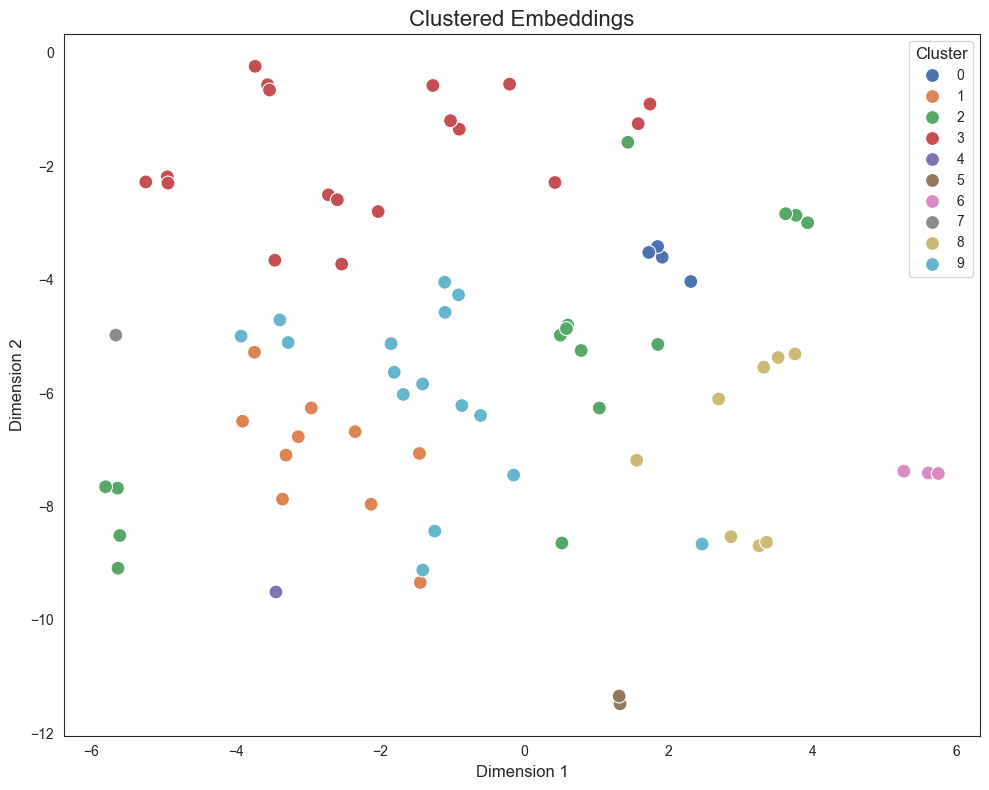

In [161]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 경고 제거
import warnings

warnings.filterwarnings("ignore")

# t-SNE 수행 및 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

# seaborn 스타일 설정
sns.set_style("white")

# 축소된 데이터 플롯
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=reduced_data_tsne[:, 0],
    y=reduced_data_tsne[:, 1],
    hue=kmeans.labels_,
    palette="deep",
    s=100,
)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.title("Clustered Embeddings", fontsize=16)
plt.legend(title="Cluster", title_fontsize=12)

# 배경색 설정
plt.gcf().patch.set_facecolor("white")

plt.tight_layout()
plt.show()

그러면 각 cluster 의 중심점에 가장 가까운 임베딩을 찾아서 저장해야 합니다.

In [162]:
import numpy as np

# 가장 가까운 점들을 저장할 빈 리스트 생성
closest_indices = []

# 클러스터 수만큼 반복
for i in range(num_clusters):

    # 해당 클러스터 중심으로부터의 거리 목록 구하기
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)

    # 가장 가까운 점의 인덱스 찾기 (argmin을 사용하여 최소 거리 찾기)
    closest_index = np.argmin(distances)

    # 해당 인덱스를 가장 가까운 인덱스 리스트에 추가
    closest_indices.append(closest_index)

In [163]:
closest_indices

[56, 18, 53, 25, 0, 44, 70, 23, 49, 64]

문서의 요약을 순서대로 진행하기 위하여 오름차순 정렬합니다.

In [164]:
# 문서의 요약을 순서대로 진행하기 위하여 오름차순 정렬
selected_indices = sorted(closest_indices)
selected_indices

[0, 18, 23, 25, 44, 49, 53, 56, 64, 70]

10개의 선택된 문서를 출력합니다. 이 과정에서 `Document` 객체를 사용하여 문서를 생성합니다.

In [165]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='2023년 12월호'),
 Document(metadata={}, page_content='∙첨단 AI 모델의 안전 테스트는 국가 안보와 안전, 사회적 피해를 포함한 여러 잠재적 유해 기능에 대한 \n시험을 포함하며, 참석자들은 정부 주도의 외부 안전 테스트에 합의\n∙각국 정부는 테스트와 기타 안전 연구를 위한 공공부문 역량에 투자하고, 테스트 결과가 다른 국가와 \n관련된 경우 해당 국가와 결과를 공유하며, 적절한 시기에 공동 표준 개발을 위해 노력하기로 합의 \nn 참가국들은 튜링상을 수상한 AI 학자인 요슈아 벤지오 교수가 주도하는 ‘과학의 현황(State of \nthe Science)’ 보고서 작성에도 합의했으며, 보고서를 통해 첨단 AI의 위험과 가능성에 관한 \n기존 연구를 과학적으로 평가하고 향후 AI 안전 연구를 위한 우선순위를 제시할 계획 \nn 한국은 영국 정부와 6개월 뒤에 온라인으로 AI 미니 정상회의를 공동 개최하기로 합의했으며, \n프랑스 정부와는 1년 후 대면 정상회의를 개최할 예정'),
 Document(metadata={}, page_content='fight continues, 2023.10.30.'),
 Document(metadata={}, page_content='∙저작권청은 생성 AI와 관련된 저작권법과 정책 이슈를 조사하고 있으며, 폭넓은 의견 수렴을 통해 \n입법과 규제 조치의 필요성을 검토할 계획\n∙FTC는 생성 AI의 개발과 배포가 소비자, 근로자, 중소기업에 피해를 줄 수 있다며 소비자의 개인정보 \n침해, 차별과 편견의 자동화, 사기 범죄 등 AI 사용과 관련된 위험에 주목\nn FTC는 저작권법에 따른 권리와 책임 범위를 넘어서는 저작권 문제에 주목하여 생성 AI로 인해 \n창작자의 경쟁력이 불공정한 피해를 볼 수 있으며, 소비자가 특정 창작자의 작품을 생성 AI가 \n만들었다고 오해할 소지가 있다고 지적\n∙저작권법에 저촉되는 행위는 불

In [166]:
# 이전에 생성한 map_refine_chain을 사용하여 요약 생성
refined_summary = map_refine_chain.invoke(selected_docs)

이 문서는 첨단 AI 모델의 안전성 향상을 위해 전 세계 각국 정부의 협력이 필요함을 강조하며, 다음 사항들을 제안합니다:

1. 정부 주도 하에 외부 안전 테스트와 공공 부문 역량 강화를 위한 투자 확대가 요구됩니다.
2. 국제적 협력을 통한 테스트 결과 공유 및 공동 표준 개발 노력이 필수적입니다.
3. AI 연구의 현 상태 분석과 미래 연구 방향 설정을 위한 ‘과학의 현황’ 보고서 작성이 추진되어야 합니다.
4. 대한민국은 영국 및 프랑스와의 AI 관련 회의를 개최하기로 합의했습니다.

이러한 조치들은 AI 기술의 안전한 발전을 보장하고 글로벌 협력을 촉진함으로써 인류에게 긍정적인 영향을 미칠 것으로 기대됩니다. 2023년 12월호에서는 이러한 중요 사안들이 중점적으로 다뤄졌습니다.

-----------------


이 문서는 첨단 AI 모델의 안전성을 향상시키기 위해 전 세계 각국 정부의 협력의 중요성을 강조하며 다음과 같은 제안을 포함하고 있습니다.


1. 정부는 외부 안전 테스트를 강화하고 공공 부문 역량을 높이기 위한 투자를 확대해야 합니다.
2. 국제적인 협력을 통해 테스트 결과를 공유하고 공동의 표준을 개발하는 노력이 필요합니다.
3. AI 연구의 현재 상태를 분석하고 미래의 연구 방향을 설정하기 위해 ‘과학의 현황’ 보고서를 작성해야 합니다.
4. 대한민국은 영국 및 프랑스와 함께 AI 관련 회의를 개최하기로 결정하였습니다.


이러한 조치들은 AI 기술의 안전한 발전과 글로벌 협력을 촉진해 인류에게 긍정적인 영향을 줄 것으로 예상되며, 2023년 12월호에서 이러한 중요한 주제들이 중점적으로 다루어졌습니다.

-----------------


이 문서는 미국 연방거래위원회(FTC)가 생성형 AI 기술과 관련하여 저작권 및 정책에 대한 우려를 제기하고 있으며, 이에 대해 다음과 같이 제안하고 있습니다.

1. 정부는 외부 안전 테스트를 강화하고 공공 부문 역량 강화를 위한 투자를 확대해야 하며, 국제적인 협력을 통해 테스트 결과를 공유

In [167]:
# 최종 결과 출력
print(refined_summary)

최근 미국 연방거래위원회(FTC)는 생성형 AI 기술과 관련된 저작권 및 정책 문제에 대해 우려를 표명한 반면, 한국은 영국 및 프랑스와의 협력을 통해 AI 기술의 안전한 발전과 글로벌 협력을 추진하고 있습니다. 한편, 삼성전자는 자체 개발한 생성 AI 모델인 '삼성 가우스'를 선보이며 온 디바이스에서 동작하며 언어, 코드, 이미지 등 세 가지 영역에 특화된 기능을 제공합니다. 

구글 역시 클라우드 경쟁력 강화를 위해 생성 AI 분야에 대규모 투자를 진행 중이며, 이를 통해 아마존과 마이크로소프트를 추월하고 기업 고객들의 클라우드 지출 증대를 목표로 삼고 있습니다. IDC 조사 결과에 따르면 향후 5년간 AI Application Development and Design(AI AD&D) 분야는 연평균 38.7%의 성장률을 보일 전망으로, 기업들은 AI 기술 활용을 통한 비즈니스 성공 달성을 위해 해당 분야에 집중적으로 투자하고 있음을 알 수 있습니다.

이에 따라 AI 기술의 진보와 국제 협력의 중요성이 강조되고 있으며, 기업들은 AI 및 자동화 기술 관련 투자 확대와 외부 AI 소프트웨어 구매 혹은 기존 시스템과의 통합 등을 적극 검토하고 있습니다. 이러한 변화는 일상 생활과 업무 방식의 혁신적 변화를 가져올 것으로 기대됩니다.

또한, AI 안전성 향상을 위한 연구소는 외부 기관과의 협력을 통해 자체 시스템 평가 방법을 개발하고, 전문가들과 의견을 교환하며 지침을 제정하는 것을 목표로 합니다. 이외에도 외부 연구자를 모집하여 AI 안전성에 관한 기초 연구를 수행하고, 효과적인 AI 거버넌스 도구 개발에 주력하며 안전한 AI 시스템 구현을 위한 새로운 방안들을 연구합니다. 개인정보보호와 데이터 규제 준수를 기반으로 여러 이해 관계자들 간의 정보 공유 채널을 구축하며, AI Safety Summit에서의 합의를 토대로 고급 AI 모델 평가 결과를 타국 정부 및 연구소와 공유하고 피해나 취약점 보고 절차를 수립한다고 발표되었습니다.

갈릴레오의 ‘LLM 환각 